In [1]:
import os
os.chdir('../')
os.getcwd()

'/home/minh_khai/skin_disease/skin-disease'

## Load Model

In [2]:
from abc import ABC, abstractmethod
from pathlib import Path

class BaseVisionModel(ABC):
    @abstractmethod
    def predict(self, imgs): ...
    
    @abstractmethod
    def save(self, path: Path) -> None: ...
    
    @abstractmethod
    def load(self, path: Path) -> None: ...
    
    @abstractmethod
    def save_onnx(self, path: Path, sample_input) -> None: ...

In [3]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, resnet50

def build_efficientnet(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = efficientnet_b0(weights="IMAGENET1K_V1")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    return model

def build_resnet(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc"):
                p.requires_grad = False
    return model

In [ ]:
from pathlib import Path
import numpy as np
import onnxruntime as ort
        
class EfficientNetONNXModel(BaseVisionModel):
    def __init__(self, num_classes: int):
        self.num_classes = num_classes
        self.session = None
        self.input_name = None

    def predict(self, imgs):
        imgs_np     = imgs.cpu().numpy() if hasattr(imgs, "cpu") else imgs
        logits      = self.session.run(None, {self.input_name: imgs_np})[0]
        exp_logits  = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs       = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        pred_idx    = int(np.argmax(probs, axis=1)[0])
        confidence  = float(probs[0, pred_idx])
        return pred_idx, confidence

    def save(self, path: Path) -> None:
        raise NotImplementedError("ONNX models are exported via save_onnx(), not saved directly.")

    def load(self, path: Path) -> None:
        self.session = ort.InferenceSession(str(path), providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name

    def save_onnx(self, path: Path, sample_input) -> None:
        raise NotImplementedError("Already in ONNX format, cannot re-export.")

2026-06-20 06:22:58.817680624 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [5]:
ONNX_MODEL_REGISTRY = {
    "efficientnet": EfficientNetONNXModel,
}

class ONNXModelFactory:
    @staticmethod
    def create(model_name: str, num_classes: int) -> BaseVisionModel:
        cls = ONNX_MODEL_REGISTRY.get(model_name)
        if not cls:
            raise ValueError(f"No ONNX model registered for: '{model_name}'.")
        return cls(num_classes)

## Define Database

In [6]:
from dataclasses import dataclass

@dataclass(frozen=True)
class PostgresConfig:
    host:   str
    port:   str
    user:   str
    password: str
    dbname: str

In [7]:
import psycopg2
from core.logger import logger

class PredictionLogger:
    def __init__(self, config: PostgresConfig):
        self.config = config
        self._init_db()
        
    def _init_db(self):
        conn = self._get_connection()
        cur  = conn.cursor()
        cur.execute(""" 
            CREATE TABLE IF NOT EXISTS prediction_logs (
                id SERIAL PRIMARY KEY,
                timestamp TIMESTAMP DEFAULT NOW(),
                image_path TEXT,
                predicted_disease TEXT,
                confidence REAL,
                needs_review BOOLEAN,
                doctor_reviewed BOOLEAN DEFAULT FALSE,
                doctor_feedback TEXT
            )   
        """)
        conn.commit(); cur.close(); conn.close()
        
    def _get_connection(self):
        return psycopg2.connect(
            host     = self.config.host,
            port     = self.config.port,
            user     = self.config.user,
            password = self.config.password,
            dbname   = self.config.dbname
        )
    
    def log_prediction(self, 
                       image_path: str, disease: str, 
                       confidence: float, needs_review: bool):
        
        conn = self._get_connection()
        cur  = conn.cursor()
        cur.execute(
            "INSERT INTO prediction_logs (image_path, predicted_disease, confidence, needs_review) VALUES (%s, %s, %s, %s) RETURNING id",
            (image_path, disease, confidence, needs_review)
        )
        log_id = cur.fetchone()[0]
        
        conn.commit(); cur.close(); conn.close()
        logger.info(f"Logged prediction id={log_id}: {disease} ({confidence:.2%})")
        return log_id
    
    def update_doctor_feedback(self, log_id: int, feedback: str):
        conn = self._get_connection()
        cur  = conn.cursor()
        cur.execute(
            "UPDATE prediction_logs SET doctor_reviewed = TRUE, doctor_feedback = %s WHERE id = %s",
            (feedback, log_id)
        )
        conn.commit(); cur.close(); conn.close()

## Defining Nodes

In [8]:
from dataclasses import dataclass
from pathlib import Path
from typing import TypedDict, Optional

@dataclass(frozen=True)
class VisionConfig:
    api_url: str
    conf_threshold: int

class AgentState(TypedDict):
    image_path:     str
    disease:        Optional[str]
    confidence:     Optional[float]
    needs_review:   Optional[bool]
    log_id:         Optional[int]
    rag_context:    Optional[str]
    recommendation: Optional[dict]
    
@dataclass(frozen=True)
class RagConfig:
    pdf_path:           Path
    chroma_dir:         Path
    embedding_model:    str
    chunk_size:         int
    chunk_overlap:      int
    top_k:              int

In [9]:
import os, json
from core.constants import *
from core import read_yaml, create_directories

class ConfigurationManager:
    def __init__(self, 
                 config_filepath=CONFIG_FILE_PATH, 
                 params_filepath=PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])
        
    def get_postgres_config(self) -> PostgresConfig:
        return PostgresConfig(
            host     = os.getenv("POSTGRES_HOST"),
            port     = os.getenv("POSTGRES_PORT"),
            user     = os.getenv("POSTGRES_USER"),
            password = os.getenv("POSTGRES_PASSWORD"),
            dbname   = os.getenv("POSTGRES_DB"),
        )

    def get_vision_config(self) -> VisionConfig:
        config = self.config.vision_config
        return VisionConfig(
            api_url        = config.api_url,           
            conf_threshold = self.params.vision_params.confidence_threshold,
        )
    
    def get_rag_config(self) -> RagConfig:
        config = self.config.rag_config
        params = self.params.rag_params

        return RagConfig(
            pdf_path        = Path(config.pdf_path),
            chroma_dir      = Path(config.chroma_dir),
            embedding_model = params.embedding_model,
            chunk_size      = params.chunk_size,
            chunk_overlap   = params.chunk_overlap,
            top_k           = params.top_k,
        )

In [10]:
from dotenv import load_dotenv
load_dotenv()
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

class RagNode:
    def __init__(self, config: RagConfig):
        self.config = config
        embedding   = HuggingFaceEmbeddings(model_name=config.embedding_model)
        self.vectorstore = Chroma(persist_directory=str(config.chroma_dir), embedding_function=embedding)
        self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": config.top_k})

    def run(self, state: AgentState) -> AgentState:
        disease = state.get("disease")
        if not disease:
            logger.warning("RagNode skipped: disease is None/empty in state")
            return {**state, "rag_context": None}

        query   = f"{disease} symptoms treatment causes"
        docs    = self.retriever.invoke(query)
        context = "\n\n".join(doc.page_content for doc in docs)

        if not docs:
            logger.warning(f"No RAG context found for disease: {disease}")

        return {**state, "rag_context": context}

/home/minh_khai/skin_disease/skin-disease/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
import torch, httpx
from PIL import Image
from torchvision import transforms

DISEASE_CLASSES = [
    "Eczema",
    "Warts, Molluscum & Viral Infections",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma (BCC)",
    "Melanocytic Nevi (NV)",
    "Benign Keratosis-like Lesions (BKL)",
    "Psoriasis & Lichen Planus",
    "Seborrheic Keratoses & Benign Tumors",
    "Tinea, Ringworm & Fungal Infections",
]

def preprocess_image(image_path: str, image_size: int) -> torch.Tensor:
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0)

class VisionNode:
    def __init__(self, config: VisionConfig, pred_logger: PredictionLogger):
        self.config = config
        self.pred_logger = pred_logger
        
    def run(self, state: AgentState) -> AgentState:
        
        with open(state["image_path"], "rb") as f:
            resp = httpx.post(
                self.config.api_url,
                files={"file": f},
                timeout=30.0,
            )
            
        resp.raise_for_status()
        result = resp.json()
        
        disease      = result["disease"]
        confidence   = result["confidence"]
        needs_review = confidence < self.config.conf_threshold

        log_id = self.pred_logger.log_prediction(state["image_path"], disease, confidence, needs_review)

        return {**state, 
                "disease": disease, 
                "confidence": confidence, 
                "needs_review": needs_review, 
                "log_id": log_id}

In [12]:
from pydantic import BaseModel, Field
from typing import Annotated

class RecommendationSchema(BaseModel):
    recommendations: Annotated[
        list[str],
        Field(description="3-5 actionable recommendations for the patient", min_length=3, max_length=5)
    ]
    next_steps: Annotated[
        list[str],
        Field(description="3-5 concrete next steps to take", min_length=3, max_length=5)
    ]
    tips: Annotated[
        list[str],
        Field(description="3-5 general care tips", min_length=3, max_length=5)
    ]

In [13]:
from dotenv import load_dotenv
load_dotenv()
from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate

SYSTEM_PROMPT = (
    "You are a professional dermatologist AI assistant. "
    # "Always respond in Vietnamese. "
    "Always recommend consulting a licensed dermatologist."
)

class RecommendNode:
    def __init__(self, model_name: str = "claude-haiku-4-5-20251001"):
        self.llm = ChatAnthropic(model=model_name).with_structured_output(RecommendationSchema)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system", SYSTEM_PROMPT),
            ("human", "Detected condition: {disease}\nConfidence: {confidence}%{context_block}\nProvide recommendations."),
        ])
        self.chain = self.prompt | self.llm

    def run(self, state: AgentState) -> AgentState:
        context_block = f"\n\nMedical reference:\n{state['rag_context']}" if state.get("rag_context") else ""
        confidence = state.get("confidence")
        confidence_str = f"{confidence*100:.1f}" if confidence is not None else "N/A"

        result: RecommendationSchema = self.chain.invoke({
            "disease":       state.get("disease", "Unknown"),
            "confidence":    confidence_str,
            "context_block": context_block,
        })

        return {**state, "recommendation": result.model_dump()}

In [14]:
# Insanity Check
state = {
    "image_path": "test.jpg",
    "disease": "Eczema",
    "confidence": 0.82,
    "needs_review": False,
    "log_id": 1,
    "rag_context": None,
    "recommendation": None,
}

recommend_node = RecommendNode()
result = recommend_node.run(state)
print(result["recommendation"])

{'recommendations': ['Use fragrance-free, hypoallergenic moisturizers regularly, especially after bathing, to maintain skin barrier function and reduce dryness', 'Avoid harsh soaps, hot water, and irritants; use lukewarm water and gentle cleansers when bathing', 'Apply topical corticosteroids or calcineurin inhibitors as prescribed during flare-ups to reduce inflammation and itching', 'Identify and avoid personal triggers such as certain fabrics, detergents, stress, or allergens that worsen your eczema', 'Consider using a humidifier to maintain adequate moisture in the air, which helps prevent skin dryness'], 'next_steps': ['Schedule an appointment with a licensed dermatologist for proper diagnosis confirmation and personalized treatment plan', 'Keep a symptom diary to track flare-ups, triggers, and what treatments work best for your skin', 'Start a consistent skincare routine with gentle, fragrance-free products suitable for sensitive skin', 'Consult with your dermatologist about pres

In [15]:
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver

def hitl_node_run(state: AgentState) -> AgentState:
    decision = interrupt({
        "type":       "low_confidence_review",
        "disease":    state["disease"],
        "confidence": state["confidence"],
        "image_path": state["image_path"],
        "log_id":     state["log_id"],
    })

    if decision.get("action") == "override":
        return {**state, "disease": decision["disease"], "needs_review": False}

    return {**state, "needs_review": False}

def route_after_vision(state: AgentState) -> str:
    return "hitl_review" if state.get("needs_review") else "rag"

def build_graph(vision_node: VisionNode, rag_node: RagNode, recommend_node: RecommendNode):
    graph = StateGraph(AgentState)

    graph.add_node("vision", vision_node.run)
    graph.add_node("rag", rag_node.run)
    graph.add_node("recommend", recommend_node.run)
    graph.add_node("hitl_review", hitl_node_run)

    graph.set_entry_point("vision")
    graph.add_conditional_edges("vision", route_after_vision, {
        "rag": "rag",
        "hitl_review": "hitl_review",
    })
    graph.add_edge("rag", "recommend")
    graph.add_edge("recommend", END)
    graph.add_edge("hitl_review", "rag")

    return graph.compile(checkpointer=MemorySaver())

[2026-06-20 06:26:37,097: INFO: __init__: yaml file: config/config.yaml loaded successfully]
[2026-06-20 06:26:37,102: INFO: __init__: yaml file: params.yaml loaded successfully]
[2026-06-20 06:26:37,104: INFO: __init__: created directory at: artifacts]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6046.29it/s]


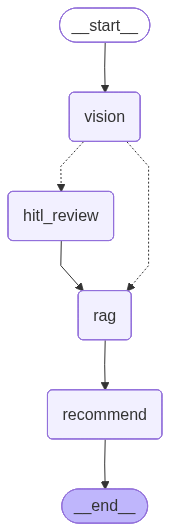

In [17]:
config_manager = ConfigurationManager()
recommend_node = RecommendNode()

rag_config = config_manager.get_rag_config()
rag_node   = RagNode(config=rag_config)

vision_config = config_manager.get_vision_config()
pred_logger   = PredictionLogger(config_manager.get_postgres_config())

vision_node = VisionNode(config=vision_config, pred_logger=pred_logger)
app = build_graph(vision_node, rag_node, recommend_node)
app

In [18]:
import uuid
from langgraph.types import Command

thread_id = str(uuid.uuid4())
run_config = {"configurable": {"thread_id": thread_id}}

result = app.invoke({"image_path": "2_6.jpg"}, config=run_config)

if "__interrupt__" in result:
    print("⚠️ New doctor's approval:", result["__interrupt__"][0].value)
    decision = {"action": "confirm"}   
    result = app.invoke(Command(resume=decision), config=run_config)
else:
    print("Interrupt was not triggered - conf > threshold")

print(result["disease"], result["confidence"])
print(result["recommendation"])

[2026-06-20 06:26:48,690: INFO: 1005939080: Logged prediction id=18: Warts, Molluscum & Viral Infections (95.99%)]
⚠️ New doctor's approval: {'type': 'low_confidence_review', 'disease': 'Warts, Molluscum & Viral Infections', 'confidence': 0.9598705172538757, 'image_path': '2_6.jpg', 'log_id': 18}
Warts, Molluscum & Viral Infections 0.9598705172538757
{'recommendations': ['Consult a licensed dermatologist for proper diagnosis and confirmation of viral infection type (warts, molluscum contagiosum, or other viral lesions)', 'Avoid touching or scratching affected areas to prevent spreading the infection to other parts of your body or to other people', 'Maintain good hygiene practices including regular handwashing and keeping affected areas clean and dry', 'Do not attempt self-treatment with over-the-counter products without professional guidance, as some treatments may be ineffective or cause irritation', 'Consider antiviral or immunomodulatory treatments prescribed by a dermatologist, whi

In [19]:
thread_id_2 = str(uuid.uuid4())
run_config_2 = {"configurable": {"thread_id": thread_id_2}}
result = app.invoke({"image_path": "2_6.jpg"}, config=run_config_2)

decision = {"action": "override", "disease": "Psoriasis & Lichen Planus"}
result = app.invoke(Command(resume=decision), config=run_config_2)
print(result["disease"])

[2026-06-20 06:26:54,726: INFO: 1005939080: Logged prediction id=19: Warts, Molluscum & Viral Infections (95.99%)]
Psoriasis & Lichen Planus


## Evaluate RAG

In [20]:
import pandas as pd

EVAL_DISEASES = [
    "Eczema",
    "Warts, Molluscum & Viral Infections",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma (BCC)",
    "Melanocytic Nevi (NV)",
    "Benign Keratosis-like Lesions (BKL)",
    "Psoriasis & Lichen Planus",
    "Seborrheic Keratoses & Benign Tumors",
    "Tinea, Ringworm & Fungal Infections",
]

def eval_retrieval(disease: str, retriever) -> dict:
    query = f"{disease} symptoms treatment causes"
    docs  = retriever.invoke(query)
    context = "\n\n".join(doc.page_content for doc in docs)
    
    key_terms = [t.strip().lower() for t in disease.replace("(", "").replace(")", "").split() if len(t) > 3]
    hit = any(term in context.lower() for term in key_terms)
    
    return {
        "disease": disease,
        "num_docs_retrieved": len(docs),
        "context_mentions_disease": hit,
        "context_preview": context[:150],
    }

retrieval_results = [eval_retrieval(d, rag_node.retriever) for d in EVAL_DISEASES]
df_retrieval = pd.DataFrame(retrieval_results)

print(f"Retrieval hit rate: {df_retrieval['context_mentions_disease'].mean():.1%}")
df_retrieval

Retrieval hit rate: 70.0%


,disease,num_docs_retrieved,context_mentions_disease,context_preview
0,Eczema,3,False,"42. Fellner MJ, Sapadin AN (2001). Current the..."
1,"Warts, Molluscum & Viral Infections",3,True,immunohistologic study and results of treatmen...
2,Melanoma,3,True,321 \n \n64. Iseman M.D. (2002). Tuberculosis ...
3,Atopic Dermatitis,3,True,"319 \n \n38. Eichenfield LF, Krakowski AC, Pig..."
4,Basal Cell Carcinoma (BCC),3,True,deficient niacin status and pellagra are endem...
5,Melanocytic Nevi (NV),3,False,321 \n \n64. Iseman M.D. (2002). Tuberculosis ...
6,Benign Keratosis-like Lesions (BKL),3,False,"319 \n \n38. Eichenfield LF, Krakowski AC, Pig..."
7,Psoriasis & Lichen Planus,3,True,pathologenesis. Rev Sci tech. 20. pp.21. \n131...
8,Seborrheic Keratoses & Benign Tumors,3,True,"319 \n \n38. Eichenfield LF, Krakowski AC, Pig..."
9,"Tinea, Ringworm & Fungal Infections",3,True,Raynaud's phenomenon. Rheumatology.46(3).pp. 5...


In [21]:
eval_records = []

for disease in EVAL_DISEASES:
    rag_state = {"disease": disease}
    rag_out   = rag_node.run(rag_state)
    context   = rag_out.get("rag_context") or ""

    rec_state = {"disease": disease, "confidence": 0.9, "rag_context": context}
    rec_out   = recommend_node.run(rec_state)
    answer    = " ".join(
        rec_out["recommendation"]["recommendations"]
        + rec_out["recommendation"]["next_steps"]
        + rec_out["recommendation"]["tips"]
    )

    eval_records.append({"disease": disease, "context": context, "answer": answer})

print(f"Generated {len(eval_records)} eval records")

Generated 10 eval records


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

def faithfulness_score(answer: str, context: str, embedding_model) -> float:
    if not context.strip():
        return None
    vecs = embedding_model.embed_documents([answer, context])
    return float(cosine_similarity([vecs[0]], [vecs[1]])[0][0])

embedding_model = rag_node.retriever.vectorstore.embeddings

for record in eval_records:
    record["faithfulness_score"] = faithfulness_score(record["answer"], record["context"], embedding_model)

df_faithfulness = pd.DataFrame(eval_records)[["disease", "faithfulness_score"]]
print(f"Mean faithfulness score: {df_faithfulness['faithfulness_score'].mean():.3f}")
df_faithfulness

Mean faithfulness score: 0.879


,disease,faithfulness_score
0,Eczema,0.879467
1,"Warts, Molluscum & Viral Infections",0.884302
2,Melanoma,0.883237
3,Atopic Dermatitis,0.862016
4,Basal Cell Carcinoma (BCC),0.878469
5,Melanocytic Nevi (NV),0.869166
6,Benign Keratosis-like Lesions (BKL),0.884694
7,Psoriasis & Lichen Planus,0.893244
8,Seborrheic Keratoses & Benign Tumors,0.862008
9,"Tinea, Ringworm & Fungal Infections",0.891639


In [23]:
import json
from langchain_anthropic import ChatAnthropic

judge = ChatAnthropic(model="claude-haiku-4-5-20251001")

sample = eval_records[:5]

prompt = (
    "Bạn là người đánh giá chất lượng câu trả lời y khoa. "
    "Với mỗi case dưới đây, đánh giá câu trả lời (answer) có DỰA TRÊN context cung cấp, "
    "không bịa thêm thông tin không có trong context. "
    "Trả lời CHỈ bằng JSON array, mỗi item: {\"disease\": str, \"faithful\": bool, \"reason\": str (ngắn gọn)}.\n\n"
)
for i, item in enumerate(sample):
    prompt += f"--- Case {i+1} ---\nDisease: {item['disease']}\nContext: {item['context'][:500]}\nAnswer: {item['answer']}\n\n"

response = judge.invoke(prompt)
print(response.content)

try:
    judge_results = json.loads(response.content)
    df_judge = pd.DataFrame(judge_results)
    print(f"\nFaithful rate (LLM judge, n=5): {df_judge['faithful'].mean():.1%}")
except json.JSONDecodeError:
    print("Claude không trả JSON sạch, xem raw output ở trên để parse tay")
    
summary = {
    "retrieval_hit_rate": df_retrieval["context_mentions_disease"].mean(),
    "mean_faithfulness_embedding": df_faithfulness["faithfulness_score"].mean(),
}
print(json.dumps(summary, indent=2))

```json
[
  {
    "disease": "Eczema",
    "faithful": false,
    "reason": "Context contains only bibliography references about pemphigus, acne, traction folliculitis, and neonatal erythroderma - no information about eczema treatment or management"
  },
  {
    "disease": "Warts, Molluscum & Viral Infections",
    "faithful": false,
    "reason": "Context only lists bibliographic references about molluscum contagiosum and other conditions - does not contain treatment or management recommendations provided in the answer"
  },
  {
    "disease": "Melanoma",
    "faithful": false,
    "reason": "Context contains only bibliography references (tuberculosis therapy, melanoma therapeutics) - no specific treatment protocols or management guidelines to support the detailed answer provided"
  },
  {
    "disease": "Atopic Dermatitis",
    "faithful": false,
    "reason": "Context only shows bibliographic references about pediatric acne and vitiligo - does not contain information about atopic de

In [24]:
rag_config = config_manager.get_rag_config()
print(rag_config.chunk_size, rag_config.chunk_overlap, rag_config.top_k, rag_config.embedding_model)

1000 200 3 intfloat/multilingual-e5-base


In [25]:
retriever_test = rag_node.vectorstore.as_retriever(search_kwargs={"k": 7})
docs = retriever_test.invoke("Nguyên nhân và cách điều trị các triệu chứng của bệnh chàm")

for i, d in enumerate(docs):
    print(f"--- Rank {i+1} ---")
    print(d.page_content[:250])
    print()

--- Rank 1 ---
có màu đỏ nhạt sau chuyển sang màu nâu. Tổn thƣơng thƣờng nhẵn, có thể có vảy 
da mỏng. Khi thời tiết nóng ẩm, ngƣời bệnh thƣờng có cảm giác ngƣ́a, kích thích và 
gãi đôi khi gây hiện tƣợng chàm hoá.   
 + Dƣới ánh sáng đèn Wood, tổn thƣơng có màu 

--- Rank 2 ---
80 
 
- Một số trƣờng hợp có biến chứng chàm hoá xung quanh tổn thƣơng do 
ngƣời bệnh gãi nhiều và do đáp ứng miễn dịch của cơ thể đối với tác nhân gây 
bệnh. 
6. PHÕNG BỆNH 
- Vệ sinh cá nhân. 
- Tránh tiếp xúc với nguồn lây bệnh, nhất là ở những n

--- Rank 3 ---
sĩ chuyên khoa nhƣ corticosteroid đƣờng toàn thân, methotrexat, cyclosporin và 
azathioprin. 
- Quang trị liệu và quang hóa trị liệu.  
5. TIẾN TRIỂN VÀ BIẾN CHỨNG 
- Bệnh lý lành tính. 
- Chà xát nhiều gây dày sừng, sẩn chắc tiến triển mạn tính. 
6.

--- Rank 4 ---
179 
 
thuốc. Theo dõi chặt chẽ diễn biến của bệnh, khi thuốc có tác dụng, bệnh giảm thì 
bắt đầu hạ liều dần. 
 + Bồi phụ nƣớc và điện giải theo điện giải đồ.  
 + Nâng cao thể trạng 

In [26]:
import fitz

doc = fitz.open(str(rag_config.pdf_path))
found_pages = []

for page_num in range(len(doc)):
    text = doc[page_num].get_text().lower()
    if "eczema" in text and ("treatment" in text or "symptom" in text or "diagnosis" in text):
        found_pages.append(page_num)
    if "chàm" in text or "sang thấp" in text:
        found_pages.append(page_num)

print(f"Tìm thấy {len(found_pages)} trang khớp: {found_pages[:10]}")

if found_pages:
    print(doc[found_pages[0]].get_text()[:500])

Tìm thấy 25 trang khớp: [12, 40, 42, 44, 49, 52, 54, 80, 114, 115]
 
12 
 
a) Tại chỗ 
- Chàm hoá: ngoài tổn thƣơng của chốc còn xuất hiện thêm các tổn thƣơng 
của chàm. Đó là các mụn nƣớc tập trung thành từng đám, phân bố quanh tổn thƣơng 
chốc hoặc rải rác khắp cơ thể, ngứa nhiều. Khi điều trị cần phối hợp điều trị chàm. 
- Chốc loét 
+ Điều kiện thuận lợi: vệ sinh kém, tiểu đƣờng, giảm bạch cầu, trẻ suy dinh 
dƣỡng hoặc sau sởi do giảm sức đề kháng. 
+ Lúc đầu là chốc thông thƣờng, nếu không đƣợc điều trị bọng nƣớc sẽ lan 
rộng, sau khi vỡ để lại vết loét sâ


In [29]:
DISEASE_VI_MAP = {
    "Eczema": "bệnh chàm",
    "Warts, Molluscum & Viral Infections": "mụn cóc, u mềm lây, nhiễm virus",
    "Melanoma": "u ác tính hắc tố melanoma",
    "Atopic Dermatitis": "viêm da cơ địa",
    "Basal Cell Carcinoma (BCC)": "ung thư biểu mô tế bào đáy",
    "Melanocytic Nevi (NV)": "nốt ruồi sắc tố",
    "Benign Keratosis-like Lesions (BKL)": "tổn thương dày sừng lành tính",
    "Psoriasis & Lichen Planus": "vảy nến và liken phẳng",
    "Seborrheic Keratoses & Benign Tumors": "dày sừng tiết bã và u lành tính",
    "Tinea, Ringworm & Fungal Infections": "nấm da, hắc lào",
}
VI_STOPWORDS = {"và", "các", "của", "là", "có", "cho", "với", "này", "khi", "do", "ở"}

class RagNode:
    def __init__(self, config: RagConfig):
        self.config = config
        embedding   = HuggingFaceEmbeddings(model_name=config.embedding_model)
        self.vectorstore = Chroma(persist_directory=str(config.chroma_dir), embedding_function=embedding)
        self.retriever = self.vectorstore.as_retriever(search_kwargs={"k": config.top_k})

    def run(self, state: AgentState) -> AgentState:
        disease = state.get("disease")
        if not disease:
            logger.warning("RagNode skipped: disease is None/empty in state")
            return {**state, "rag_context": None}

        query = f"{DISEASE_VI_MAP.get(disease, disease)} nguyên nhân triệu chứng điều trị"
        docs    = self.retriever.invoke(query)
        context = "\n\n".join(doc.page_content for doc in docs)

        if not docs:
            logger.warning(f"No RAG context found for disease: {disease}")

        return {**state, "rag_context": context}

rag_node   = RagNode(config=rag_config)
    
def eval_retrieval(disease: str, rag_node, vi_map: dict) -> dict:
    rag_out = rag_node.run({"disease": disease})
    context = (rag_out.get("rag_context") or "").lower()

    vi_term = vi_map.get(disease, disease).lower().replace(",", "")
    key_terms = [t for t in vi_term.split() if t not in VI_STOPWORDS]
    hit = any(term in context for term in key_terms)

    return {"disease": disease, "context_mentions_disease": hit, "context_preview": context[:150]}

retrieval_results = [eval_retrieval(d, rag_node, DISEASE_VI_MAP) for d in EVAL_DISEASES]
df_retrieval = pd.DataFrame(retrieval_results)
print(f"Retrieval hit rate: {df_retrieval['context_mentions_disease'].mean():.1%}")
print(df_retrieval.to_string())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3521.25it/s]


Retrieval hit rate: 100.0%
                                disease  context_mentions_disease                                                                                                                                                  context_preview
0                                Eczema                      True        80 \n \n- một số trƣờng hợp có biến chứng chàm hoá xung quanh tổn thƣơng do \nngƣời bệnh gãi nhiều và do đáp ứng miễn dịch của cơ thể đối với tác nhân g
1   Warts, Molluscum & Viral Infections                      True  82 \n \nb) chẩn đoán phân biệt \n- viêm da dầu \n- trứng cá đỏ \n- lao da \n- dày sừng do nắng (actinic keratosis) \n- dị ứng thuốc \n4. điều trị \n- dùng các 
2                              Melanoma                      True         4 máu thiếu máu, thiếu máu thiếu sắt \n5 ung thƣ các ung thƣ biểu mô, đa u tủy, u lympho ác tính (đặc biệt u \nlympho hodgkin, mycosis fungoides), bệnh 
3                     Atopic Dermatitis                      True

In [30]:
DISEASE_DISTINCTIVE_TERM = {
    "Eczema": "chàm",
    "Warts, Molluscum & Viral Infections": "mụn cóc",
    "Melanoma": "hắc tố",
    "Atopic Dermatitis": "viêm da cơ địa",
    "Basal Cell Carcinoma (BCC)": "tế bào đáy",
    "Melanocytic Nevi (NV)": "nốt ruồi",
    "Benign Keratosis-like Lesions (BKL)": "dày sừng",
    "Psoriasis & Lichen Planus": "vảy nến",
    "Seborrheic Keratoses & Benign Tumors": "tiết bã",
    "Tinea, Ringworm & Fungal Infections": "nấm sợi",
}

def eval_retrieval(disease: str, rag_node, term_map: dict) -> dict:
    rag_out = rag_node.run({"disease": disease})
    context = (rag_out.get("rag_context") or "").lower()

    term = term_map.get(disease, disease).lower()
    hit  = term in context   # check nguyên cụm từ, không tách rời từng từ

    return {"disease": disease, "context_mentions_disease": hit, "context_preview": context[:150]}

retrieval_results = [eval_retrieval(d, rag_node, DISEASE_DISTINCTIVE_TERM) for d in EVAL_DISEASES]
df_retrieval = pd.DataFrame(retrieval_results)
print(f"Retrieval hit rate: {df_retrieval['context_mentions_disease'].mean():.1%}")
print(df_retrieval.to_string())

Retrieval hit rate: 80.0%
                                disease  context_mentions_disease                                                                                                                                                  context_preview
0                                Eczema                      True        80 \n \n- một số trƣờng hợp có biến chứng chàm hoá xung quanh tổn thƣơng do \nngƣời bệnh gãi nhiều và do đáp ứng miễn dịch của cơ thể đối với tác nhân g
1   Warts, Molluscum & Viral Infections                     False  82 \n \nb) chẩn đoán phân biệt \n- viêm da dầu \n- trứng cá đỏ \n- lao da \n- dày sừng do nắng (actinic keratosis) \n- dị ứng thuốc \n4. điều trị \n- dùng các 
2                              Melanoma                      True         4 máu thiếu máu, thiếu máu thiếu sắt \n5 ung thƣ các ung thƣ biểu mô, đa u tủy, u lympho ác tính (đặc biệt u \nlympho hodgkin, mycosis fungoides), bệnh 
3                     Atopic Dermatitis                      True 